# Notebook 1.- Exploratory Data Analysis.
- Objetivo: Revisar y comprender el dataset.
- Dataset: Palmer Penguins Dataset Extended
- Herramientas: Pandas, matplotlib, seaborn

## 0. Importacion del dataset, copia del mismo y creacion del test_set

In [1]:
# Importacion de librerias necesarias para este notebook
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_original = pd.read_csv(r"E:\ROAD_TO_DATA_SCIENCE\PROYECTS\penguin-species-classification\data\raw\palmerpenguins_extended.csv")

In [3]:
df_penguins = df_original.copy()

In [4]:
from sklearn.model_selection import train_test_split
penguin_train_set, penguin_test_set = train_test_split(df_penguins, test_size=0.2, random_state=42)

Se crea esta division desde esta fase tan temprana debido a que el cerebro es una increible maquina de deteccion de patrones, lo que podria despues generar sesgos asi que unicamente se revisaran los datos referentes al penguin_train_set

## 1. Informacion general

In [5]:
penguin_train_set.shape

(2744, 11)

El dataset de train tiene:
- Filas: 2744
- Columnas: 11

In [6]:
penguin_train_set.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
1258,Adelie,Torgensen,30.9,13.7,199.0,4901.0,female,krill,adult,healthy,2023
932,Gentoo,Biscoe,24.8,17.5,205.0,5940.0,male,krill,juvenile,overweight,2022
572,Adelie,Torgensen,62.5,14.5,206.0,4664.0,female,fish,juvenile,overweight,2022
736,Chinstrap,Dream,32.0,17.4,211.0,4357.0,male,krill,juvenile,underweight,2022
2288,Gentoo,Biscoe,56.7,17.7,235.0,5689.0,female,fish,juvenile,overweight,2024


## 2. Tipos de variables

In [7]:
penguin_train_set.info()

<class 'pandas.DataFrame'>
Index: 2744 entries, 1258 to 3174
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            2744 non-null   str    
 1   island             2744 non-null   str    
 2   bill_length_mm     2744 non-null   float64
 3   bill_depth_mm      2744 non-null   float64
 4   flipper_length_mm  2744 non-null   float64
 5   body_mass_g        2744 non-null   float64
 6   sex                2744 non-null   str    
 7   diet               2744 non-null   str    
 8   life_stage         2744 non-null   str    
 9   health_metrics     2744 non-null   str    
 10  year               2744 non-null   int64  
dtypes: float64(4), int64(1), str(6)
memory usage: 257.2 KB


- Cualitativas: 
    - Species
    - Island
    - Sex
    - Diet
    - Life_stage
    - health_metrics
- Cuantitativas:
    - bill_lenght_mm
    - bill_depth_mm
    - flipper_length_mm
    - body_mass_g
    - year


In [8]:
target_col = ['species']
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']
cat_cols = ['island', 'sex', 'diet', 'life_stage', 'health_metrics']

## 3. Valores Faltantes

In [9]:
# Mostrar cuantos nulos hay y que porcentaje representan por columna
resumen_nulos = penguin_train_set.isna().sum().to_frame(name='Total Nulos')
resumen_nulos['Porcentaje %'] = (penguin_train_set.isna().mean() * 100).round(2)
print(resumen_nulos.sort_values(by='Total Nulos', ascending=False))

                   Total Nulos  Porcentaje %
species                      0           0.0
island                       0           0.0
bill_length_mm               0           0.0
bill_depth_mm                0           0.0
flipper_length_mm            0           0.0
body_mass_g                  0           0.0
sex                          0           0.0
diet                         0           0.0
life_stage                   0           0.0
health_metrics               0           0.0
year                         0           0.0


El dataset no presenta valores nulos en ninguna de sus columnas, no habra que realizar imputacion

## 4. Distribuciones

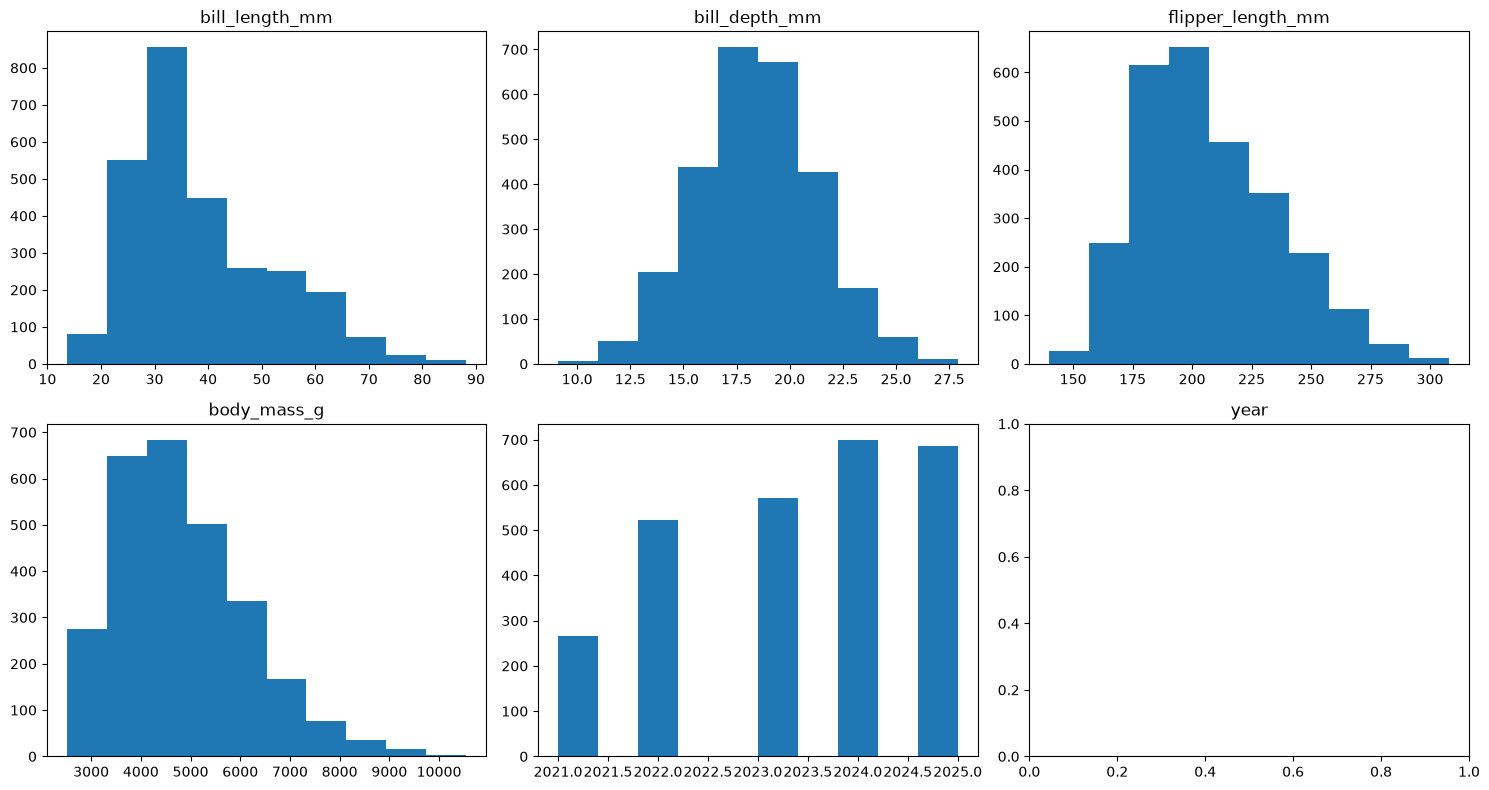

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(15,8))

axs[0,0].hist(penguin_train_set[num_cols[0]])
axs[0,0].set_title(f"{num_cols[0]}")

axs[0,1].hist(penguin_train_set[num_cols[1]])
axs[0,1].set_title(f"{num_cols[1]}")

axs[0,2].hist(penguin_train_set[num_cols[2]])
axs[0,2].set_title(f"{num_cols[2]}")

axs[1,0].hist(penguin_train_set[num_cols[3]])
axs[1,0].set_title(f"{num_cols[3]}")

axs[1,1].hist(penguin_train_set[num_cols[4]])
axs[1,2].set_title(num_cols[4])


plt.tight_layout()
plt.show()

Observaciones:
- bill_length_mm = Distribucion sesgada hacia la izquierda (requiere transformacion)
- bill_depth_mm = Distribucion normal (no requiere transformacion)
- flipper_length_mm = Distribucion sesgada hacia la izquierda (requiere transformacion)
- body_mass_g = Distribucion sesgada hacia la izquierda (requiere transformacion)
- year = Es categorica por eso se observa esa forma de columnas separradas

Ademas todas cuentan con escalas muy distintas, requieren escalamiento, de no realizar estas acciones los modelos podrian darle importancia a valores mas altos sin en realidad tener mas importancia, lo que llevaria a incrementar el error reducible

## 5. Outliers

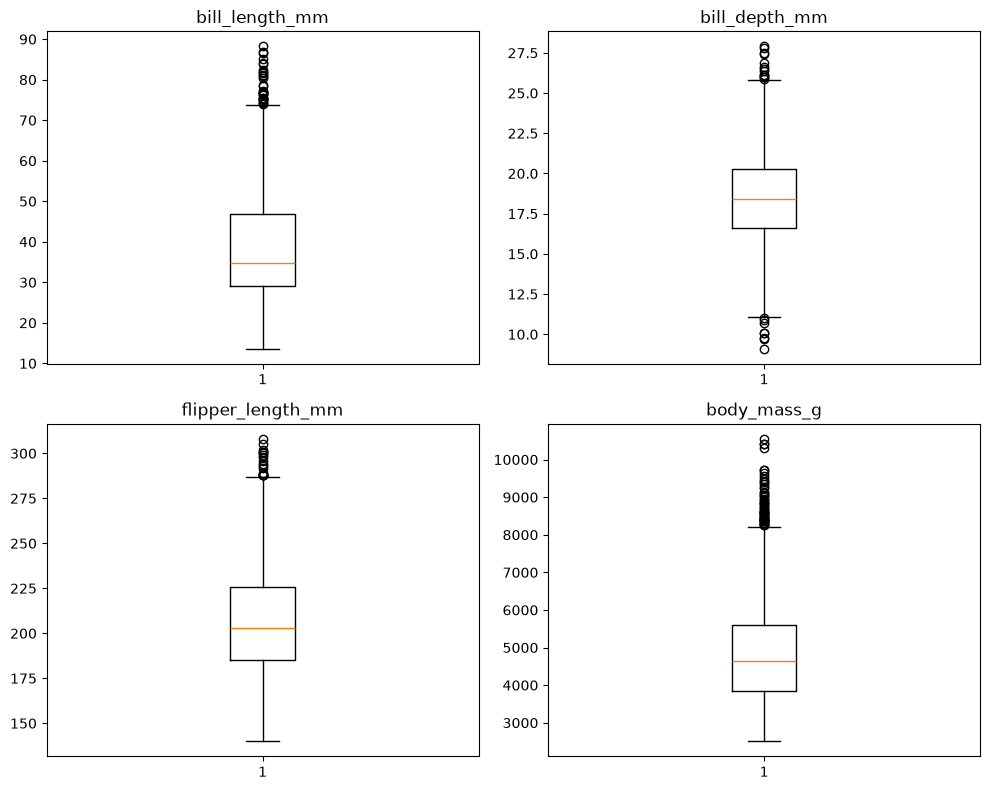

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(10,8))

axs[0,0].boxplot(penguin_train_set[num_cols[0]])
axs[0,0].set_title(f"{num_cols[0]}")

axs[0,1].boxplot(penguin_train_set[num_cols[1]])
axs[0,1].set_title(f"{num_cols[1]}")

axs[1,0].boxplot(penguin_train_set[num_cols[2]])
axs[1,0].set_title(f"{num_cols[2]}")

axs[1,1].boxplot(penguin_train_set[num_cols[3]])
axs[1,1].set_title(f"{num_cols[3]}")



plt.tight_layout()
plt.show()

In [12]:
for i in num_cols:
    # Calcular los cuartiles (Q1 y Q3)
    q1 = penguin_train_set[i].quantile(0.25)
    q3 = penguin_train_set[i].quantile(0.75)

    # Calcular IQR
    iqr = q3 - q1

    # Definir limites
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    # Filtrar outliers
    outliers = penguin_train_set[(penguin_train_set[i] < limite_inferior) | (penguin_train_set[i] > limite_superior)]

    # Calcular el porcentaje de outliers
    porcentaje_outliers = (len(outliers) / len(penguin_train_set) * 100)

    print(f"Porcentaje de outliers de {i}: {porcentaje_outliers:.2f}%")

Porcentaje de outliers de bill_length_mm: 1.02%
Porcentaje de outliers de bill_depth_mm: 0.77%
Porcentaje de outliers de flipper_length_mm: 0.66%
Porcentaje de outliers de body_mass_g: 1.97%
Porcentaje de outliers de year: 0.00%


Todas presentan outlier pero no son una gran cantidad dentro de los features.

## 6. Balance de clases

In [13]:
# Categorias en variables categoricas
i = 0
while(i < len(cat_cols)):
    print("-" * 20)
    print(f"Categorias de {cat_cols[i]}")
    print(penguin_train_set[cat_cols[i]].value_counts())
    i+=1

--------------------
Categorias de island
island
Biscoe       1401
Dream         911
Torgensen     432
Name: count, dtype: int64
--------------------
Categorias de sex
sex
male      1382
female    1362
Name: count, dtype: int64
--------------------
Categorias de diet
diet
krill       1123
fish         774
parental     691
squid        156
Name: count, dtype: int64
--------------------
Categorias de life_stage
life_stage
juvenile    1235
adult        818
chick        691
Name: count, dtype: int64
--------------------
Categorias de health_metrics
health_metrics
healthy        1237
overweight      938
underweight     569
Name: count, dtype: int64


Observaciones:
Ninguna de las variables categoricas tiene una gran cantidad de categorias asi que se puede manejar simplemente con one hot encoding

## 7. Correlaciones

Utilizaremos ANOVA ya que realizaremos una clasificacion multidimensional (3 dimensiones en este caso) si el P-valor es menor a 0.05 esta variable si tiene relacion e impacto con el target (especies)

In [14]:
import scipy.stats as stats

In [ ]:
resultados = {}

# Calcular ANOVA para cada variable numerica
for i in num_cols:
    # Agrupar datos numericos segun las 3 categorias del target
    grupos = [penguin_train_set[i][penguin_train_set[target_col] == cat] for cat in penguin_train_set[target_col].dropna().unique()]

    # Ejecutar test ANOVA
    f_stat, p_val = stats.f_oneway(*grupos)
    resultados[i] = {'F-Statistic': f_stat, 'P-Value': p_val}


df_resultados = pd.DataFrame(resultados).T.sort_values(by='P-Value')
print(df_resultados)
    

SyntaxError: invalid syntax (667404102.py, line 13)

: 